|<img style="float:left;" src="images/usherb_transp.gif"> |Pierre Proulx, ing, professeur|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|

### Section18.5 <img src='images/Chap-18-Section-18-5.png' height =500 width=500> 

In [1]:
# -*- coding: utf-8 -*-
#
# Pierre Proulx
#
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)

In [2]:
# Paramètres, variables et fonctions
eta=sp.symbols('eta')                                                            
phi=sp.Function('phi')(eta)
Q=sp.Function('Q')(eta)

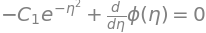

In [3]:
#
# La solution est similaire à celle du chapitre 4, on utilisera d'abord cette solution ensuite on insèrera les
# variables voulues
#
eq1=sp.Eq(Q.diff(eta)+2*eta*Q,0)
Q=sp.dsolve(eq1).rhs                  
eq=sp.Eq(phi.diff(eta)-Q,0)
display(eq)

In [4]:
phi=sp.dsolve(eq).rhs
display(phi)

In [5]:
cl1=sp.Eq(Q.subs(eta,0),1)          # puisque en eta=0 la constante C2 disparait,
#                                     on solutionne tout de suite C1
constante1=sp.solve(cl1,sp.symbols('C1'),dict=True)
display(constante1)

In [6]:
phi=phi.subs(constante1[0]) # C1 est dans une liste de 1 élément, voir ci-haut.
cl2=sp.Eq(phi.subs(eta,sp.oo),0)
display(cl2)

In [7]:
constante2=sp.solve(cl2,sp.symbols('C2'),dict=True)
phi=phi.subs(constante2[0])
display(phi)

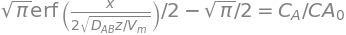

In [8]:
#
#  On remplace eta et phi , 4.1-14 devient 18.5-16
#
CA,CA0=sp.symbols('C_A CA0')
x,DAB,z,Vmax=sp.symbols('x,D_AB,z,V_m')
etaCh18=x/(sp.sqrt(4*DAB*z/Vmax))
C=sp.Eq(phi.subs(eta,etaCh18),CA/CA0)
display(C)

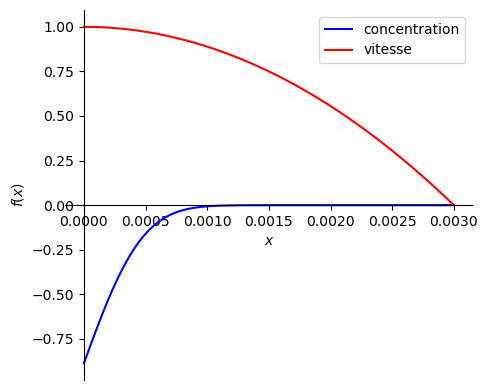

/tmp/ipykernel_33556/372575351.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  couleurs=plt.cm.get_cmap("Spectral") # Il y a des dizaines de mappings de couleurs disponibles


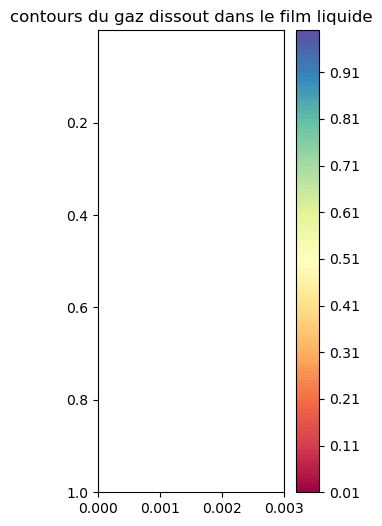

In [9]:
%matplotlib inline
#
# On pourrait maintenant voir l'effet des paramètres sur le profil 
# afin de comparer avec la figure 18.5-1
#
# Valeurs estimées des paramètres en utilisant la diffusivité de l'hélium dans l'eau, c'est 
# un tout petit atome qui diffusera donc très rapidement
#
dico={'D_AB':7e-9,'V_m':.1} 
Cplot=C.lhs.subs(dico)
delta=0.003                          # film de 3 millimètres, essayez de varier la position z pour voir
Vzplot=1-x**2/delta**2               # la combinaison profil de concentration-profil de vitesse
#                                      comme sur la figure 18.5-1. Voir aussi les contours ci-après
#                                      La simplification v=v_max est-elle justifiée???
#
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=5,4
p=sp.plot((Cplot.subs(z,1),(x,0,delta)),(Vzplot,(x,0,delta)),show=False,legend=True)
p[0].line_color='blue'
p[0].label='concentration'
p[1].line_color='red'
p[1].label='vitesse'
p.show()
#
# Traçons maintenant les iso-concentrations dans le film
#
import numpy as np
Delta=0.003
nx=60
L=1
nz=100
X=np.linspace(0,Delta,nx)
Z=np.linspace(1e-10,L,nz)   # parce qu'on peut pas tracer en z=0, la concentration devient infinie!
niveaux=np.linspace(1e-2,1,100) # de 0.01 à 1, 100 niveaux.
f=np.ones(((nz,nx)))
for i in range(0,nz):
    for j in range(0,nx):
        f[i,j]=Cplot.subs(z,Z[i]).subs(x,X[j]).evalf()  
plt.rcParams['figure.figsize']=3,6
ZZ,XX=np.meshgrid(Z,X)
couleurs=plt.cm.get_cmap("Spectral") # Il y a des dizaines de mappings de couleurs disponibles
contours=plt.contourf(X,Z,f , niveaux, cmap=couleurs)
plt.gca().invert_yaxis()  # cette petite fonction renverse l'axe y, quelle belle initiative... 
plt.colorbar()            # car si on n'utilise pas, le graphe sera du bas en haut, pas comme la figure
plt.title('contours du gaz dissout dans le film liquide')
plt.show() 

<img src='images/Chap-18-Section-18-5.png' align='left' width=600 height=600>